In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [2]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(device)

mps


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    "chest_xray/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    "chest_xray/test",
    transform=test_transform
)

print(train_dataset.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9602616].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8208281].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].


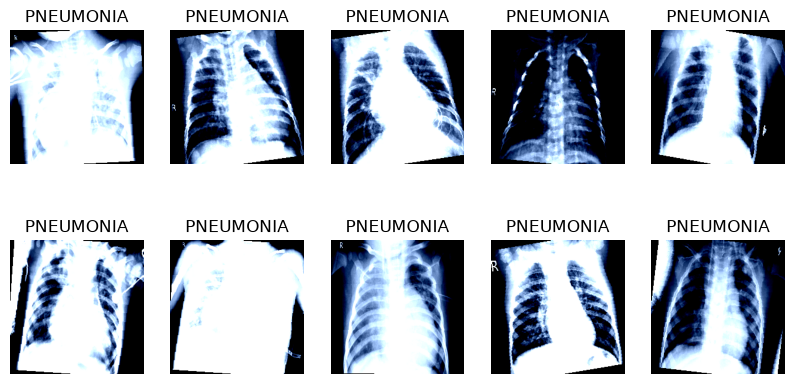

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,5)
)

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        train_dataset.classes[
            labels[i]
        ]
    )

    ax.axis("off")

plt.show()

In [7]:
model = resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "pneumonia_resnet18.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [8]:
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = 100 * correct / total

print(
    f"Accuracy: {accuracy:.2f}%"
)

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

Accuracy: 88.46%
[[163  71]
 [  1 389]]
              precision    recall  f1-score   support

      NORMAL       0.99      0.70      0.82       234
   PNEUMONIA       0.85      1.00      0.92       390

    accuracy                           0.88       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.88      0.88       624



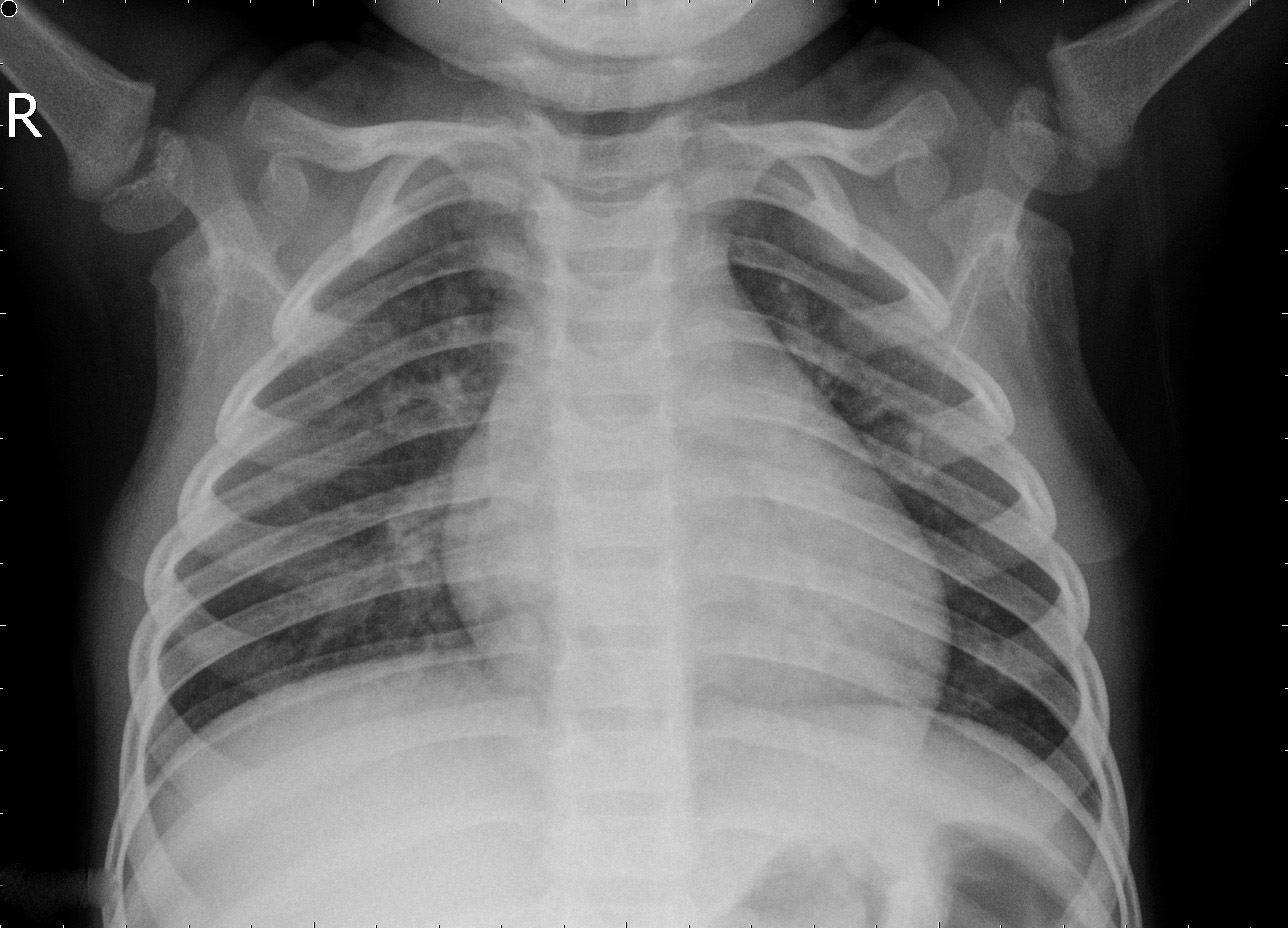

In [9]:
image_path = (
    "chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg"
)

raw_image = Image.open(
    image_path
).convert("L")

display(raw_image)

In [10]:
gradcam_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

input_tensor = (
    gradcam_transform(raw_image)
    .unsqueeze(0)
    .to(device)
)

In [11]:
target_layer = (
    model.layer4[-1].conv2
)

activations = []
gradients = []

def forward_hook(
    module,
    inp,
    out
):
    activations.append(out)

def backward_hook(
    module,
    grad_in,
    grad_out
):
    gradients.append(
        grad_out[0]
    )
    
forward_handle = (
    target_layer.register_forward_hook(
        forward_hook
    )
)

backward_handle = (
    target_layer.register_full_backward_hook(
        backward_hook
    )
)

In [12]:
output = model(
    input_tensor
)

probabilities = torch.softmax(
    output,
    dim=1
)

prediction = (
    probabilities.argmax(1)
)

confidence = (
    probabilities.max()
    .item()
    * 100
)

print(
    "Prediction:",
    train_dataset.classes[
        prediction.item()
    ]
)

print(
    f"Confidence: "
    f"{confidence:.2f}%"
)

Prediction: NORMAL
Confidence: 93.64%


In [13]:
model.zero_grad()

score = output[
    0,
    prediction.item()
]

score.backward()

In [14]:
activation = (
    activations[0]
    .detach()
    .cpu()
)

gradient = (
    gradients[0]
    .detach()
    .cpu()
)

weights = gradient.mean(
    dim=(2,3),
    keepdim=True
)

cam = (
    weights *
    activation
).sum(dim=1)

cam = torch.relu(
    cam
).squeeze()

cam -= cam.min()

cam /= (
    cam.max() + 1e-8
)

cam = cam.numpy()

In [15]:
cam_image = Image.fromarray(
    np.uint8(
        cam * 255
    )
)

cam_image = cam_image.resize(
    raw_image.size
)

cam = (
    np.array(cam_image)
    / 255.0
)

In [16]:
max_y, max_x = np.unravel_index(
    np.argmax(cam),
    cam.shape
)

height, width = cam.shape

vertical = max_y / height
horizontal = max_x / width

if vertical < 0.33:
    lung_level = "Upper Lung"
elif vertical < 0.66:
    lung_level = "Middle Lung"
else:
    lung_level = "Lower Lung"

if horizontal < 0.5:
    side = "Left Lung"
else:
    side = "Right Lung"

region = (
    f"{lung_level} "
    f"{side}"
)

print(
    "Attention Region:",
    region
)

Attention Region: Lower Lung Left Lung


In [ ]:
prediction_name = (
    train_dataset.classes[
        prediction.item()
    ]
)

report = f"""
AI RADIOLOGY REPORT

Prediction:
{prediction_name}

Confidence:
{confidence:.2f}%

Primary Attention Region:
{region}

Interpretation:
The neural network focused most strongly
on the {region.lower()} when producing
its prediction.
"""

print(report)


AI RADIOLOGY REPORT

Prediction:
NORMAL

Confidence:
93.64%

Primary Attention Region:
Lower Lung Left Lung

Interpretation:
The neural network focused most strongly
on the lower lung left lung when producing
its prediction.

This report is generated from model
attention patterns and should not be
considered a medical diagnosis.



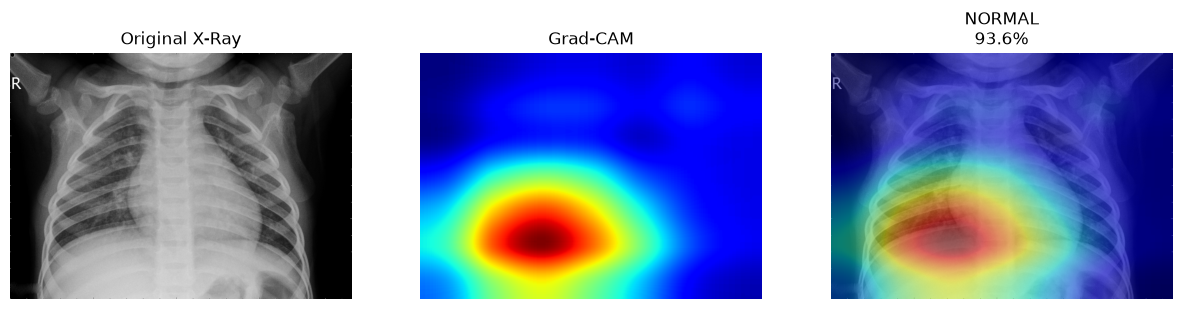

In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

axes[0].imshow(
    raw_image,
    cmap="gray"
)
axes[0].set_title(
    "Original X-Ray"
)
axes[0].axis("off")

axes[1].imshow(
    cam,
    cmap="jet"
)
axes[1].set_title(
    "Grad-CAM"
)
axes[1].axis("off")

axes[2].imshow(
    raw_image,
    cmap="gray"
)

axes[2].imshow(
    cam,
    cmap="jet",
    alpha=0.5
)

axes[2].set_title(
    f"{prediction_name}\n"
    f"{confidence:.1f}%"
)

axes[2].axis("off")

plt.show()